# Valorant Win Prediction — Tabular Stats + Toxicity

Predict the `win` label for VCT match-team rows using:

1. **Logistic Regression** — linear baseline
2. **Random Forest** — non-linear baseline
3. **XGBoost (tuned)** — main model with `RandomizedSearchCV`

The final analysis ranks features (XGBoost importance + SHAP) to test the
hypothesis: *does `toxicity_score` correlate with match outcome?*

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

RANDOM_STATE = 42

df = pd.read_csv('data/vct_final_model_ready.csv')
print("Shape:", df.shape)
print("Win base rate:", round(df['win'].mean(), 3))
df.head()

Shape: (53914, 37)
Win base rate: 0.499


,year,Tournament,Stage,Match Type,Match Name,Map,Team,opponent,attacker_score,defender_score,...,Initiated_Pistol_Won,Won_$_won,Won_$$_won,Won_$$$_won,Won_Eco_won,Won_Pistol_Won,win,chat_message,toxicity_score,toxicity
0,2021,Valorant Champions 2021,Group Stage,Opening (D),Vision Strikers vs FULL SENSE,Haven,Vision Strikers,FULL SENSE,9,4.0,...,0.0,0.0,1.0,10.0,2.0,2.0,1,you guys are bots,0.9024,1
1,2021,Valorant Champions 2021,Group Stage,Opening (D),Vision Strikers vs FULL SENSE,Breeze,Vision Strikers,FULL SENSE,9,4.0,...,0.0,0.0,1.0,11.0,1.0,1.0,1,unlucky,0.0184,0
2,2021,Valorant Champions 2021,Group Stage,Opening (C),Team Vikings vs Crazy Raccoon,Icebox,Team Vikings,Crazy Raccoon,6,7.0,...,0.0,0.0,3.0,9.0,1.0,1.0,1,good half,0.0182,0
3,2021,Valorant Champions 2021,Group Stage,Opening (C),Team Vikings vs Crazy Raccoon,Haven,Team Vikings,Crazy Raccoon,6,7.0,...,0.0,0.0,4.0,7.0,2.0,2.0,1,tutorial level,0.9100,1
4,2021,Valorant Champions 2021,Group Stage,Opening (D),FNATIC vs Cloud9,Icebox,FNATIC,Cloud9,7,6.0,...,0.0,0.0,0.0,13.0,0.0,0.0,1,report instalock jett,0.0521,0


In [20]:
# --- feature selection ---
# Drop direct leakage (these encode the result), identifier/categorical metadata,
# and the raw chat text (we already have its toxicity_score).
LEAKY = ['team_score', 'opponent_score', 'score_diff',
         'attacker_score', 'defender_score', 'overtime_score']
META  = ['year', 'Tournament', 'Stage', 'Match Type', 'Match Name',
         'Map', 'Team', 'opponent', 'chat_message']
TARGET = 'win'

feature_cols = [c for c in df.columns if c not in LEAKY + META + [TARGET]]
X = df[feature_cols].copy()
y = df[TARGET].astype(int)

# Drop any rows with NaNs in the kept features
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]
print(f"Using {len(feature_cols)} features on {len(X):,} rows")
print("Features:", feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, "  Test:", X_test.shape)

Using 24 features on 53,914 rows
Features: ['avg_rating', 'avg_acs', 'total_kills', 'total_deaths', 'total_assists', 'kd_diff', 'avg_kast', 'avg_adr', 'avg_headshot_pct', 'total_first_kills', 'total_first_deaths', 'fkd_diff', 'Initiated_$_won', 'Initiated_$$_won', 'Initiated_$$$_won', 'Initiated_Eco_won', 'Initiated_Pistol_Won', 'Won_$_won', 'Won_$$_won', 'Won_$$$_won', 'Won_Eco_won', 'Won_Pistol_Won', 'toxicity_score', 'toxicity']
Train: (43131, 24)   Test: (10783, 24)


## 1. Baseline — Logistic Regression
Linear lower bound. Features are scaled because they live on very different
scales (kills vs. headshot %).

In [21]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)

lr_pred  = logreg.predict(X_test_s)
lr_proba = logreg.predict_proba(X_test_s)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}\n")
print(classification_report(y_test, lr_pred))

Accuracy : 0.9872
ROC-AUC  : 0.9993

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5402
           1       0.99      0.99      0.99      5381

    accuracy                           0.99     10783
   macro avg       0.99      0.99      0.99     10783
weighted avg       0.99      0.99      0.99     10783



## 2. Baseline — Random Forest
Captures non-linear interactions. Beating LogReg here means the data has
non-linear structure that a tree ensemble can exploit.

In [22]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    n_jobs=-1, random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}\n")
print(classification_report(y_test, rf_pred))

Accuracy : 0.9610
ROC-AUC  : 0.9954

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      5402
           1       0.96      0.96      0.96      5381

    accuracy                           0.96     10783
   macro avg       0.96      0.96      0.96     10783
weighted avg       0.96      0.96      0.96     10783



## 3. Main model — XGBoost with `RandomizedSearchCV`

Sweeps `learning_rate`, `max_depth`, `n_estimators`, `subsample`,
`colsample_bytree`. 25 random configs × 3-fold CV = 75 fits, scored by
ROC-AUC.

> Tip: swap `RandomizedSearchCV` for `GridSearchCV` if you want exhaustive
> coverage — it's a drop-in replacement, just much slower.

In [23]:
param_dist = {
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'max_depth'       : [3, 5, 7, 9],
    'n_estimators'    : [100, 200, 400, 600],
    'subsample'       : [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

search = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=25, scoring='roc_auc',
    cv=3, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

print("\nBest params      :", search.best_params_)
print(f"Best CV ROC-AUC  : {search.best_score_:.4f}")

best_xgb  = search.best_estimator_
xgb_pred  = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

print(f"\nTest Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Test ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}\n")
print(classification_report(y_test, xgb_pred))

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best params      : {'subsample': 0.85, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.85}
Best CV ROC-AUC  : 0.9990

Test Accuracy : 0.9851
Test ROC-AUC  : 0.9992

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5402
           1       0.98      0.99      0.99      5381

    accuracy                           0.99     10783
   macro avg       0.99      0.99      0.99     10783
weighted avg       0.99      0.99      0.99     10783



## Model comparison

              Model  Accuracy  ROC-AUC
Logistic Regression  0.987202 0.999301
      Random Forest  0.961050 0.995386
    XGBoost (tuned)  0.985069 0.999152


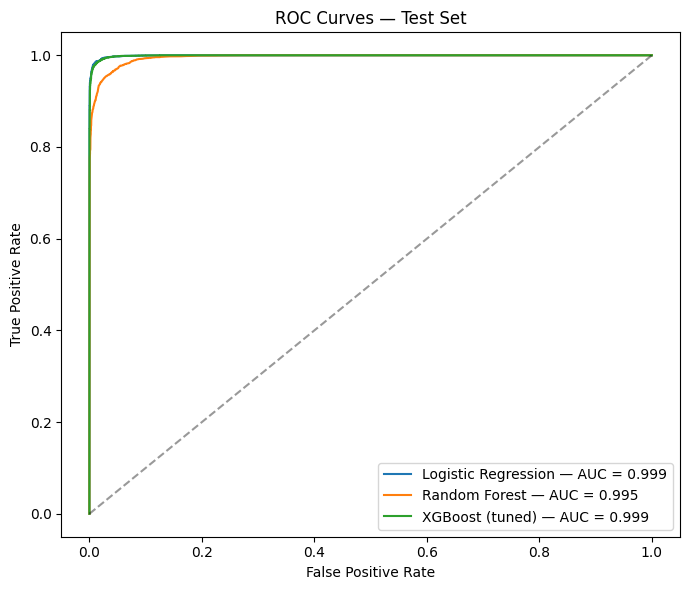

In [24]:
results = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest', 'XGBoost (tuned)'],
    'Accuracy': [accuracy_score(y_test, lr_pred),
                 accuracy_score(y_test, rf_pred),
                 accuracy_score(y_test, xgb_pred)],
    'ROC-AUC' : [roc_auc_score(y_test, lr_proba),
                 roc_auc_score(y_test, rf_proba),
                 roc_auc_score(y_test, xgb_proba)],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in [('Logistic Regression', lr_proba),
                    ('Random Forest',       rf_proba),
                    ('XGBoost (tuned)',     xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} — AUC = {roc_auc_score(y_test, proba):.3f}")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Feature importance — where does `toxicity_score` rank?

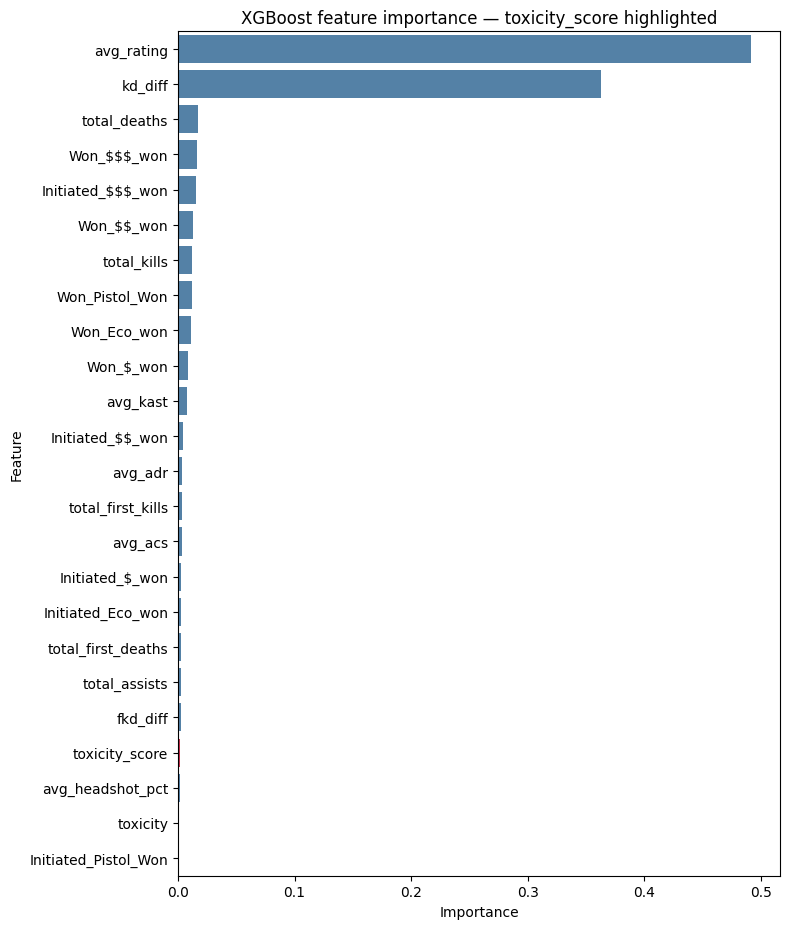

toxicity_score rank: 21 of 24

             feature  importance
          avg_rating    0.491733
             kd_diff    0.362361
        total_deaths    0.017193
         Won_$$$_won    0.016290
   Initiated_$$$_won    0.015508
          Won_$$_won    0.012704
         total_kills    0.012015
      Won_Pistol_Won    0.011915
         Won_Eco_won    0.011172
           Won_$_won    0.008974
            avg_kast    0.007865
    Initiated_$$_won    0.004645
             avg_adr    0.003542
   total_first_kills    0.003361
             avg_acs    0.003303
     Initiated_$_won    0.002927
   Initiated_Eco_won    0.002818
  total_first_deaths    0.002465
       total_assists    0.002222
            fkd_diff    0.002123
      toxicity_score    0.002047
    avg_headshot_pct    0.002026
            toxicity    0.000789
Initiated_Pistol_Won    0.000000


In [25]:
imp = (
    pd.DataFrame({
        'feature': feature_cols,
        'importance': best_xgb.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# Escape $ signs so matplotlib does not interpret them as mathtext
imp['feature_display'] = (
    imp['feature']
    .astype(str)
    .str.replace('$', r'\$', regex=False)
)

palette = [
    'crimson' if f == 'toxicity_score' else 'steelblue'
    for f in imp['feature']
]

plt.figure(figsize=(8, 0.35 * len(imp) + 1))

sns.barplot(
    data=imp,
    y='feature_display',
    x='importance',
    palette=palette
)

plt.title('XGBoost feature importance — toxicity_score highlighted')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

tox_rank = int(
    imp.index[imp['feature'] == 'toxicity_score'][0]
) + 1

print(f"toxicity_score rank: {tox_rank} of {len(imp)}\n")

# Print original feature names (not escaped)
print(
    imp[['feature', 'importance']]
    .to_string(index=False)
)

## 5. SHAP — direction and magnitude per feature

`TreeExplainer` on a 2 000-row sample of the test set.
The bar plot shows mean |SHAP|; the dot plot shows how high vs. low feature
values push the model toward win = 1.

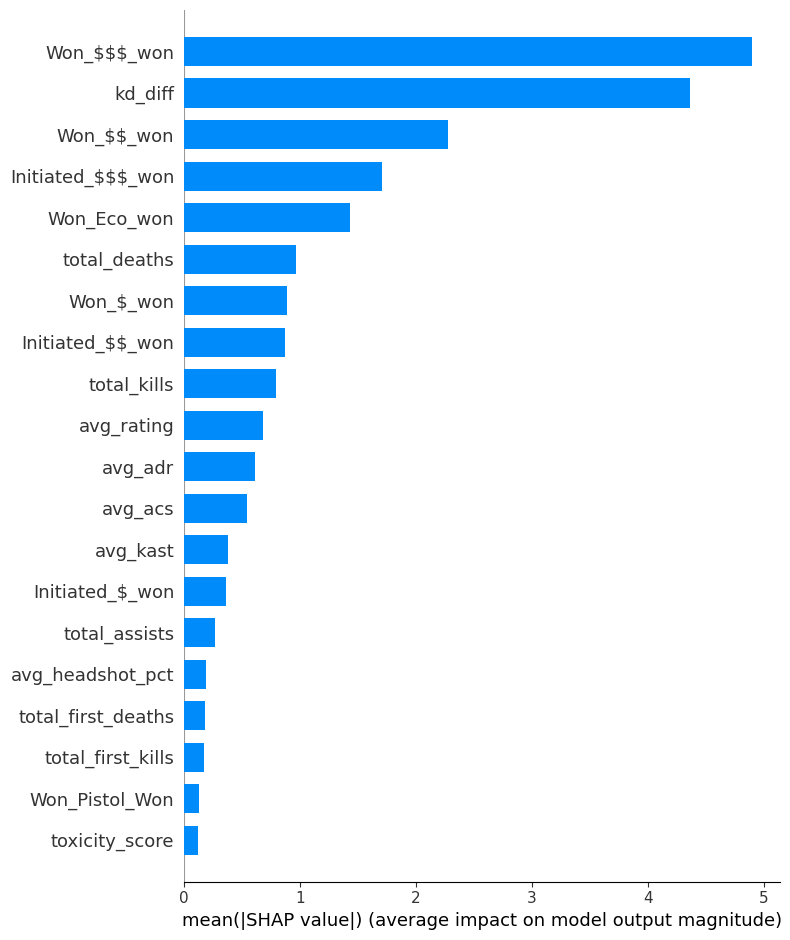

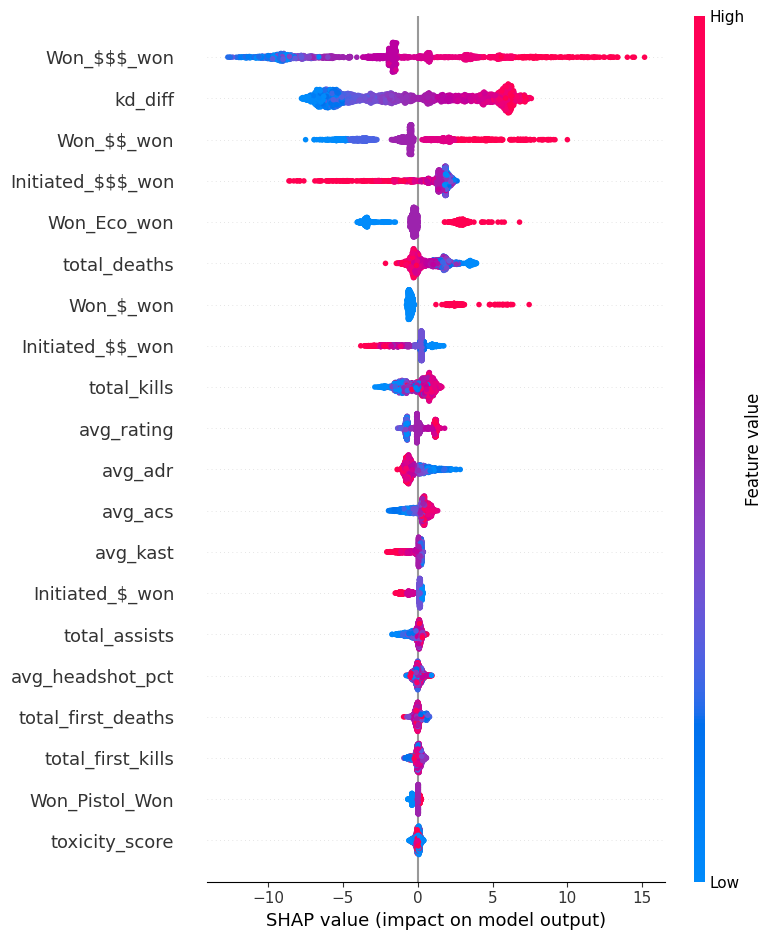

In [26]:
sample = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=RANDOM_STATE
)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(sample)

# Create a display-safe copy for plotting
sample_plot = sample.copy()

sample_plot.columns = [
    str(col).replace('$', r'\$')
    for col in sample_plot.columns
]

# SHAP bar summary
shap.summary_plot(
    shap_values,
    sample_plot,
    plot_type='bar',
    show=True
)

# SHAP beeswarm summary
shap.summary_plot(
    shap_values,
    sample_plot,
    show=True
)

## 6. Conclusion

Use the printed `toxicity_score rank` above:

- **Top-5** → strong support for the hypothesis that toxic chat behaviour is
  informative about match outcome (signal beyond raw gameplay stats).
- **Mid-pack** → toxicity contributes some signal but is dominated by direct
  performance features (rounds won by buy type, K/D, first-blood diff).
- **Bottom** → toxicity does not separate winners from losers in this dataset.

### Caveat for this specific dataset

The `toxicity_score` was generated *symmetrically* from `score_diff` and
`kd_diff`: both big wins ("ez", "free elo") and big losses ("team diff",
"uninstall") produce high toxicity scores. Magnitude of toxicity alone
therefore tells the model little about *which* team in the row won. A
stronger test of the hypothesis would use either:

- real chat logs attributed to the team that produced them, or
- a generator that only emits toxic chat in the *losing* condition.